# Assimilating only the small scale of L05 to update the entire state - both in the case that we know the true h(x) relating the small scale to the full state and in the data driven case.

In [5]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy
from scipy.io import loadmat
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import kaleido

from DAPyr.MISC import rkhs_likelihood, diff_map_ext_nystrom
from DAPyr.MODELS import deconstruct_Z_circulant
from ipywidgets import *

reload(dap)

np.set_printoptions(suppress=True)


In [3]:
uoep = {'mu': 0, 'sigma': 0.5} 
poep = {'mu': 0, 'sigma': 0.5} 
uoep_small_sc = {'mu': 0, 'sigma': 0.01} 
poep_small_sc = {'mu': 0, 'sigma': 0.01} 

# First, we look at assimilating obs directly (i.e. with the known forward operator).
- For consistency with the data-driven experiment, we start by assimilating anchor obs for the same duration as the training period.


In [4]:
e_name = 'l05-true-split'
e_split_true = dap.Expt(e_name, {'expt_flag': 1,
                       'model_flag':2,
                       'localize':1,
                       'obf': 10,
                       'seed': 58,
                       'h_flag': 3,
                       'roi': 0.2,
                       'Nt_eff': 0.8,
                       'log_every': 20,
                       'anchor_obs': True,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_small_sc,
                       'prescribed_obs_err_params': poep_small_sc,
                       'save_keest_pab':1,
                       'small_win': 4,
                       'kddm_flag': 1,
                       'Ne':80,
                       'T': 2000,
                       'T_train': 200,
                       'saveForecastEns': True,
                       'saveEnsMean': True})


In [5]:
dap.runDA(e_split_true)
e_split_true.saveExpt()

/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 3.5426601187250144
DB: RMSE at time 20: 1.6834578663473492
DB: RMSE at time 40: 0.8250909939562417
DB: RMSE at time 60: 1.0493752877215894
DB: RMSE at time 80: 1.1134832921440436
DB: RMSE at time 100: 0.8973493261542734
DB: RMSE at time 120: 0.9679661398239321
DB: RMSE at time 140: 0.8366449694572953
DB: RMSE at time 160: 0.8910990121902976
DB: RMSE at time 180: 0.9064567505266019
DB: RMSE at time 200: 0.5788119583748653
DB: RMSE at time 220: 0.8387105351166824
DB: RMSE at time 240: 2.202121529504884
DB: RMSE at time 260: 1.9977380021817885
DB: RMSE at time 280: 1.5815264772196178
DB: RMSE at time 300: 1.1784055392502666
DB: RMSE at time 320: 1.5099128628436191
DB: RMSE at time 340: 0.9139729840381088
DB: RMSE at time 360: 0.9211340980132671
DB: RMSE at time 380: 0.8941002704755641
DB: RMSE at time 400: 0.91808225717973
DB: RMSE at time 420: 1.3270045603010947
DB: RMSE at time 440: 1.8239325535758768
DB: RMSE at time 460: 2.2919103714656828
DB: RMSE at time 480: 1.3

# The data driven approach. 

- For each obs, the associated state vector used for training is the neighborhood of grid points within 24 of the location of the observation (i.e. an interval of length 2*24+1 = 49 centered at the location of the obs).
- Training is done using the first 200 cycles, using the true state. This makes for a total of 200 * 480/10 = 9600 training points, so that the lookup table used later on is 9600x9600.
- For now, training is performed online-ish - i.e. we only perform training once at t=200, and then use the resulting likelihood estimates for the remainder of the experiment.
- The knn fraction is set to 0.1, and only the 50 largest eigenvectors are retained.
- Bandwidth is chosen adaptively as the median distance between training points when only the k nearest neighbors are considered.

In [6]:
e_name = 'l05-kecd-split-truth'

e_split_kecd_tr = dap.copyExpt(e_split_true)
e_split_kecd_tr.modExptName(e_name)
e_split_kecd_tr.modExpt({'expt_flag': 3,
                       'nle_type': 4,
                       'Nb': 24,
                       'nle_every': 10000, 
                       'Neig': 50,
                       'knn_frac': 0.1,
                       'save_keest_pab': 1,
                       'bw_dm': 'knn_adaptive'})

In [7]:

dap.runDA(e_split_kecd_tr)
e_split_kecd_tr.saveExpt()

/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 3.5426601187250144
DB: RMSE at time 20: 1.6834578663473492
DB: RMSE at time 40: 0.8250909939562417
DB: RMSE at time 60: 1.0493752877215894
DB: RMSE at time 80: 1.1134832921440436
DB: RMSE at time 100: 0.8973493261542734
DB: RMSE at time 120: 0.9679661398239321
DB: RMSE at time 140: 0.8366449694572953
DB: RMSE at time 160: 0.8910990121902976
DB: RMSE at time 180: 0.9064567505266019
knn is: 961, number of samples = 9600
using median distance without 0s: 0.7314710399748828
knn is: 961, number of samples = 9600
using median distance without 0s: 0.0041282979995328015
DB: RMSE at time 200: 0.7026161736179692
DB: RMSE at time 220: 2.384464186609357
DB: RMSE at time 240: 3.7232812722448148
DB: RMSE at time 260: 2.003610473918309
DB: RMSE at time 280: 2.1534070644375656
DB: RMSE at time 300: 1.9282345527186333
DB: RMSE at time 320: 3.3623861317073604
DB: RMSE at time 340: 1.8243835506688355
DB: RMSE at time 360: 2.253010950590259
DB: RMSE at time 380: 1.8965950098706275
DB: 

# We also try with training on random samples from posterior members, as opposed to on the truth.

In [8]:
e_name = 'l05-kecd-split'

e_split_kecd = dap.copyExpt(e_split_true)
e_split_kecd.modExptName(e_name)
e_split_kecd.modExpt({'expt_flag': 3,
                       'nle_type': 5,
                       'Nb': 24,
                       'nle_every': 10000, 
                       'Neig': 50,
                       'knn_frac': 0.1,
                       'save_keest_pab': 1,
                       'bw_dm': 'knn_adaptive'})

In [9]:
dap.runDA(e_split_kecd)
e_split_kecd.saveExpt()

/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 3.5426601187250144
DB: RMSE at time 20: 1.6834578663473492
DB: RMSE at time 40: 0.8250909939562417
DB: RMSE at time 60: 1.0493752877215894
DB: RMSE at time 80: 1.1134832921440436
DB: RMSE at time 100: 0.8973493261542734
DB: RMSE at time 120: 0.9679661398239321
DB: RMSE at time 140: 0.8366449694572953
DB: RMSE at time 160: 0.8910990121902976
DB: RMSE at time 180: 0.9064567505266019
knn is: 961, number of samples = 9600
using median distance without 0s: 0.7216989990618299
knn is: 961, number of samples = 9600
using median distance without 0s: 0.0041282979995328015
DB: RMSE at time 200: 0.7039165853730623
DB: RMSE at time 220: 2.3882633525313404
DB: RMSE at time 240: 3.9475398230724794
DB: RMSE at time 260: 2.602624527061229
DB: RMSE at time 280: 2.2919252676487307
DB: RMSE at time 300: 2.0549254317930274
DB: RMSE at time 320: 3.39807328880811
DB: RMSE at time 340: 1.8407298411888702
DB: RMSE at time 360: 2.312305722535033
DB: RMSE at time 380: 2.0127307847888605
DB: R

# Let's also get a little more ambitious and try doing fully online estimation. This should be a harder problem, because our analyses (although still decent) are definitely degraded when we try to just assimilate the small-scale-only obs.

In [10]:
e_name = 'l05-kecd-split-online'

e_split_kecd_online = dap.copyExpt(e_split_true)
e_split_kecd_online.modExptName(e_name)
e_split_kecd_online.modExpt({'expt_flag': 3,
                       'nle_type': 5,
                       'Nb': 24,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': 0.1,
                       'save_keest_pab': 1,
                       'bw_dm': 'knn_adaptive'})

In [11]:
dap.runDA(e_split_kecd_online)
e_split_kecd_online.saveExpt()

/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 3.5426601187250144
DB: RMSE at time 20: 1.6834578663473492
DB: RMSE at time 40: 0.8250909939562417
DB: RMSE at time 60: 1.0493752877215894
DB: RMSE at time 80: 1.1134832921440436
DB: RMSE at time 100: 0.8973493261542734
DB: RMSE at time 120: 0.9679661398239321
DB: RMSE at time 140: 0.8366449694572953
DB: RMSE at time 160: 0.8910990121902976
DB: RMSE at time 180: 0.9064567505266019
knn is: 961, number of samples = 9600
using median distance without 0s: 0.7216989990618299
knn is: 961, number of samples = 9600
using median distance without 0s: 0.0041282979995328015
DB: RMSE at time 200: 0.7039165853730623
DB: RMSE at time 220: 2.3882633525313404
DB: RMSE at time 240: 3.9475398230724794
knn is: 961, number of samples = 9600
using median distance without 0s: 0.748631617252316
knn is: 961, number of samples = 9600
using median distance without 0s: 0.004937995927984565
DB: RMSE at time 260: 2.7999836393559554
DB: RMSE at time 280: 2.33633470723327
knn is: 961, number of sa

# Finally, let's do a no DA run for comparison:

In [12]:
e_name = 'l05-noda-split'
e_split_noda = dap.copyExpt(e_split_true)
e_split_noda.modExptName(e_name)
e_split_noda.modExpt({'expt_flag': 2})

In [13]:
dap.runDA(e_split_noda)
e_split_noda.saveExpt()

DB: RMSE at time 0: 3.872174724839312
DB: RMSE at time 20: 3.8167090710121103
DB: RMSE at time 40: 3.525011025227201
DB: RMSE at time 60: 4.879717942865352
DB: RMSE at time 80: 4.48531190761297
DB: RMSE at time 100: 4.185142846350444
DB: RMSE at time 120: 4.424044557942621
DB: RMSE at time 140: 4.879647141622774
DB: RMSE at time 160: 4.736492192938952
DB: RMSE at time 180: 4.798036631191168
DB: RMSE at time 200: 5.212547119857809
DB: RMSE at time 220: 4.2227408840657095
DB: RMSE at time 240: 4.664828395063224
DB: RMSE at time 260: 5.225635868403751
DB: RMSE at time 280: 5.270831666735459
DB: RMSE at time 300: 5.199200220931743
DB: RMSE at time 320: 4.8400642803236575
DB: RMSE at time 340: 4.95240675584638
DB: RMSE at time 360: 5.0341565345308865
DB: RMSE at time 380: 5.446717785969807
DB: RMSE at time 400: 5.182006972852713
DB: RMSE at time 420: 5.0952284828995795
DB: RMSE at time 440: 5.4500097262493785
DB: RMSE at time 460: 5.673254552742827
DB: RMSE at time 480: 5.313805594479697
DB

# With our experiments complete, let's do some plotting.
## First, just a look at RMSEs.

Known h(x) RMSE:
2.068140342910499
No DA RMSE:
4.69293128908588
KECD FROM RSFP RMSE:
2.4741339332782974
KECD ONLINE RMSE:
2.93269487123471
KECD FROM TRUTH:
2.448350075581756


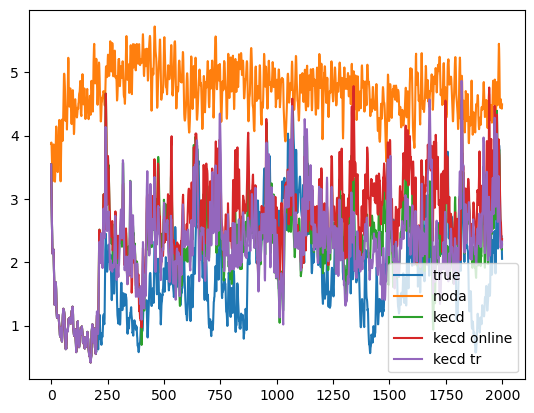

In [6]:
e_split_true = dap.loadExpt('data/experiments/scale-sep/l05-true-split.expt')
e_split_kecd = dap.loadExpt('data/experiments/scale-sep/l05-kecd-split.expt')
e_split_kecd_online = dap.loadExpt('data/experiments/scale-sep/l05-kecd-split-online.expt')
e_split_kecd_tr = dap.loadExpt('data/experiments/scale-sep/l05-kecd-split-truth.expt')
e_split_noda = dap.loadExpt('data/experiments/scale-sep/l05-noda-split.expt')

plt.plot(e_split_true.rmse, label='true')
plt.plot(e_split_noda.rmse, label='noda')
plt.plot(e_split_kecd.rmse, label='kecd')
plt.plot(e_split_kecd_online.rmse, label='kecd online')
plt.plot(e_split_kecd_tr.rmse, label='kecd tr')

print('Known h(x) RMSE:')
print(e_split_true.rmse[500:].mean())
print('No DA RMSE:')
print(e_split_noda.rmse[500:].mean())
print('KECD FROM RSFP RMSE:')
print(e_split_kecd.rmse[500:].mean())
print('KECD ONLINE RMSE:')
print(e_split_kecd_online.rmse[500:].mean())
print('KECD FROM TRUTH:')
print(e_split_kecd_tr.rmse[500:].mean())

plt.legend()

## How do these analyses actually look compared to the truth?

In [17]:
obf=10
small_win=4

def plot_scale_sep(t, ne, which, show_small_scales, show_fens_member, show_noda_ens, show_obs, show_aens_member, show_truth, show_ens_mean, show_noda_mean):

    if which == 'true h(x)':
        xf = e_split_true.x_fore_ens
        xa = e_split_true.x_ens
        xt = e_split_true.getStates()[1]
        Y = e_split_true.getStates()[2]
        xam = e_split_true.x_ensmean
    elif which == 'kecd':
        xf = e_split_kecd.x_fore_ens
        xa = e_split_kecd.x_ens
        xt = e_split_kecd.getStates()[1]
        Y = e_split_kecd.getStates()[2]
        xam = e_split_kecd.x_ensmean
    elif which == 'kecd online':
        xf = e_split_kecd_online.x_fore_ens
        xa = e_split_kecd_online.x_ens
        xt = e_split_kecd_online.getStates()[1]
        Y = e_split_kecd_online.getStates()[2]
        xam = e_split_kecd_online.x_ensmean
    elif which == 'kecd tr':
        xf = e_split_kecd_tr.x_fore_ens
        xa = e_split_kecd_tr.x_ens
        xt = e_split_kecd_tr.getStates()[1]
        Y = e_split_kecd_tr.getStates()[2]
        xam = e_split_kecd_tr.x_ensmean

    if show_truth:
        plt.plot(xt[:,t], c='k', label='truth')
        if show_obs:
            plt.scatter(np.arange(0,480,obf), Y[:,t,:], c='k', s=6)

    if show_fens_member:
        xf_smallscale = deconstruct_Z_circulant(xf[:,:,t])[1]
        hx = dap.MISC.h_weighted_mat(xf_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hx[:, ne], c='r', s=6)
        plt.plot(xf[:,ne,t], c='r', label=f'bg ens member {ne}')
        
    if show_aens_member:
        xa_smallscale = deconstruct_Z_circulant(xa[:,:,t])[1]
        hxa = dap.MISC.h_weighted_mat(xa_smallscale, obf, small_win)
        if show_obs:
            plt.scatter(np.arange(0,480,obf), hxa[:, ne], c='blue', s=6)
        plt.plot(xa[:,ne,t], c='blue', label=f'post ens member {ne}')

    if show_small_scales:
        if show_truth:
            xt_smallscale = deconstruct_Z_circulant(xt)[1]
            plt.plot(xt_smallscale[:,t], c='k', linewidth=1)
        if show_fens_member:
            plt.plot(xf_smallscale[:,ne], c='r', linewidth=1)
        if show_aens_member:
            plt.plot(xa_smallscale[:,ne], c='blue', linewidth=1)

    if show_ens_mean:
        plt.plot(xam[:,t], label='ens mean')
        
    if show_noda_mean:
        plt.plot(e_split_noda.x_ensmean[:,t], label='noda mean')

    if show_noda_ens:
        xa_noda = e_split_noda.x_ens
        plt.plot(xa_noda[:,ne,t], c='magenta', label = f'noda member {ne}')
        
        
    
    #plt.legend(loc=4)
    plt.ylim(-15, 20)
    plt.xticks([])
    plt.yticks([])

interact(
    plot_scale_sep,
    t=IntSlider(min=1, max=1999, step=1, value=0),
    ne=IntSlider(min=1, max=79, step=1, value=0),
    which = RadioButtons(options=['true h(x)','kecd', 'kecd online', 'kecd tr'], description = 'experiment:'),
    show_small_scales=Checkbox(options=['True','False'], description='plot small scale:'),
    show_obs=Checkbox(options=['True','False'], description='plot obs space quantities:'),
    show_fens_member=Checkbox(options=['True','False'], description='plot forecast ensemble member:'),
    show_aens_member=Checkbox(options=['True','False'], description='plot analysis ensemble member:'),
    show_ens_mean=Checkbox(options=['True','False'], description='plot ensemble mean:'),
    show_noda_mean=Checkbox(options=['True','False'], description='plot noda mean:'),
    show_noda_ens=Checkbox(options=['True','False'], description='plot noda ens members:'),
    show_truth=Checkbox(options=['True','False'], description='plot truth and obs:', value=True),
);


interactive(children=(IntSlider(value=1, description='t', max=1999, min=1), IntSlider(value=1, description='ne…

In [9]:
def plot_pab_given_states_plotly(x_train, y_train, pab, states):
    ys = np.sort(y_train[0, :])
    ind2 = np.argsort(y_train[0, :])
    diff = np.diff(ys)
    # Subplots: 1 row, 3 columns
    fig = make_subplots(
        rows=1, cols=3, 
        column_widths=[0.25, 0.25, 0.50],
        subplot_titles=(
            'Sample Training Data', 
            'p(y | x) - Small Scale h(x)', 
            'RMSE - Small Scale h(x)'
        ),
        horizontal_spacing=0.06
    )
    # Colorblind-friendly palette for states (left & middle plots)
    states_palette = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#000000']

    # Highly distinct colorblind-safe colors for the rightmost plot (True, NoDA, KECD)
    right_colors = {
        'True h(x)': '#000000', # Black
        'NoDA': '#D55E00',      # Vermillion / Orange-Red
        'KECD': '#56B4E9'       # Sky Blue
    }
    htp = []
    for i, state in enumerate(states):
        color = states_palette[i % len(states_palette)]
        # Calculate closest training sample
        dists = np.sum((state - x_train.T)**2, axis=1)
        ind1 = np.argsort(dists)[0]
        h = pab[ind2, ind1]
        # Normalize for plotting
        normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
        h_norm = h / normalization
        htp.append(h_norm)
        # --- Plot Column 1: Sample Training Data Points ---
        fig.add_trace(
            go.Scatter(
                y=state, 
                mode='lines', 
                line=dict(color=color, width=2),
                showlegend=False
            ),
            row=1, col=1
        )
        # --- Plot Column 2: Probability Density ---
        fig.add_trace(
            go.Scatter(
                x=ys, 
                y=h_norm, 
                mode='lines', 
                line=dict(color=color, width=2.5),
                showlegend=False
            ),
            row=1, col=2
        )
    # --- Plot Column 3: RMSE Comparison (Colorblind-Safe) ---
    fig.add_trace(
        go.Scatter(
            y=e_split_true.rmse, 
            mode='lines', 
            name='True h(x)', 
            line=dict(color=right_colors['True h(x)'], width=2.5),
            showlegend=True
        ),
        row=1, col=3
    )
    fig.add_trace(
        go.Scatter(
            y=e_split_noda.rmse, 
            mode='lines', 
            name='NoDA', 
            line=dict(color=right_colors['NoDA'], width=2.5),
            showlegend=True
        ),
        row=1, col=3
    )
    fig.add_trace(
        go.Scatter(
            y=e_split_kecd.rmse, 
            mode='lines', 
            name='KECD', 
            line=dict(color=right_colors['KECD'], width=2.5),
            showlegend=True
        ),
        row=1, col=3
    )
    # --- Global Layout Adjustments ---
    fig.update_layout(
        template='plotly_white',
        height=500,
        width=1000,
        margin=dict(l=60, r=40, t=80, b=60, autoexpand=True),
        # Position the legend vertically inside the third plot canvas area
        # x=0.55 places it inside the left edge of subplot 3 (which spans 0.50 to 1.0)
        legend=dict(
            orientation="v",
            yanchor="top",
            y=0.95,
            xanchor="left",
            x=0.87,
            bgcolor="rgba(255, 255, 255, 0.8)", # Semi-transparent background
            bordercolor="black",
            borderwidth=1
        )
    )
    # Axis Styling: Box frame with ticks ONLY on bottom and left
    axis_config = dict(
        showgrid=False,
        zeroline=False,
        showline=True,
        linewidth=1.5,
        linecolor='black',
        ticks='outside',
        tickwidth=1.5,
        tickcolor='black',
        mirror=True,  # Outer border frame line is drawn, but has no ticks
        automargin=True
    )
    # Apply configuration to all axes
    fig.update_xaxes(axis_config)
    fig.update_yaxes(axis_config)
    # Axis Specific Ranges, Labels, and tight Standoffs
    # Col 1
    fig.update_yaxes(
        title=dict(text='L05 Model State', standoff=2), 
        range=[-15, 20], 
        row=1, col=1
    )
    # Col 2
    fig.update_xaxes(title_text='y', range=[-0.02, 0.6], row=1, col=2)
    fig.update_yaxes(
        title=dict(text='p(y | x)', standoff=2), 
        range=[0, np.max(htp) * 1.05], 
        row=1, col=2
    )
    # Col 3
    fig.update_xaxes(title_text='Cycle #', row=1, col=3)
    fig.update_yaxes(
        title=dict(text='RMSE', standoff=2), 
        row=1, col=3
    )
    return fig

In [11]:
rng = np.random.default_rng(7)
inds = rng.choice(np.arange(9600), size=5)
fig = plot_pab_given_states_plotly(e_split_kecd.x_train, e_split_kecd.y_train, e_split_kecd.keest_pab, e_split_kecd.x_train[:,inds].T)
fig.write_html('l05-split.html')
fig.write_image('l05-split.png', scale=2)

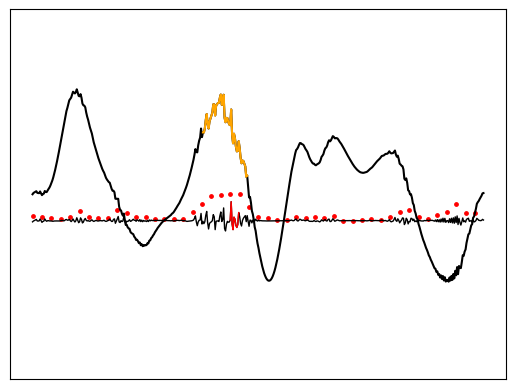

In [43]:
plot_scale_sep(t, 0, 'kecd', True, False, False, False, False, True, False, False)
xt = e_split_true.getStates()[1]
xt_smallscale = deconstruct_Z_circulant(xt)[1]
xt_smallscale[:210] = np.nan
xt_smallscale[220:] = np.nan
plt.plot(xt_smallscale[:,t], c='red', linewidth=1)
Y = e_split_true.getStates()[2]
plt.scatter(np.arange(0,480,10), 6*Y[:,t,:], c='red', s=6)

xt[:181] = np.nan
xt[229:] = np.nan
plt.plot(xt[:,t], c='orange', label='truth')
plt.savefig('data/temp/f4.png')
